In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df=pd.read_csv("E:/internship project/website performance analysis/website raw dataset  (1).csv")

In [21]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [22]:
df.columns=df.iloc[0]
df=df.drop(index=0).reset_index(drop=True)
df.columns =["Channel group","DateHour","Users","Sessions","Engaged sessions","Average engagement time per session","Engaged session per user","Event per session","Engagement rate","Event count"]

In [23]:
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged session per user,Event per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Channel group                        3182 non-null   object
 1   DateHour                             3182 non-null   object
 2   Users                                3182 non-null   object
 3   Sessions                             3182 non-null   object
 4   Engaged sessions                     3182 non-null   object
 5   Average engagement time per session  3182 non-null   object
 6   Engaged session per user             3182 non-null   object
 7   Event per session                    3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


In [25]:
df["DateHour"]=pd.to_datetime(df["DateHour"],format="%Y%m%d%H",errors="coerce")
numeric_col=df.columns.drop(["Channel group","DateHour"])
df[numeric_col]=df[numeric_col].apply(pd.to_numeric,errors="coerce")
df["Hour"]=df["DateHour"].dt.hour

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Channel group                        3182 non-null   object        
 1   DateHour                             3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged sessions                     3182 non-null   int64         
 5   Average engagement time per session  3182 non-null   float64       
 6   Engaged session per user             3182 non-null   float64       
 7   Event per session                    3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hour        

In [27]:
df.describe()

,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged session per user,Event per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


### sessions and user over time 

In [28]:
sns.set(style="whitegrid")


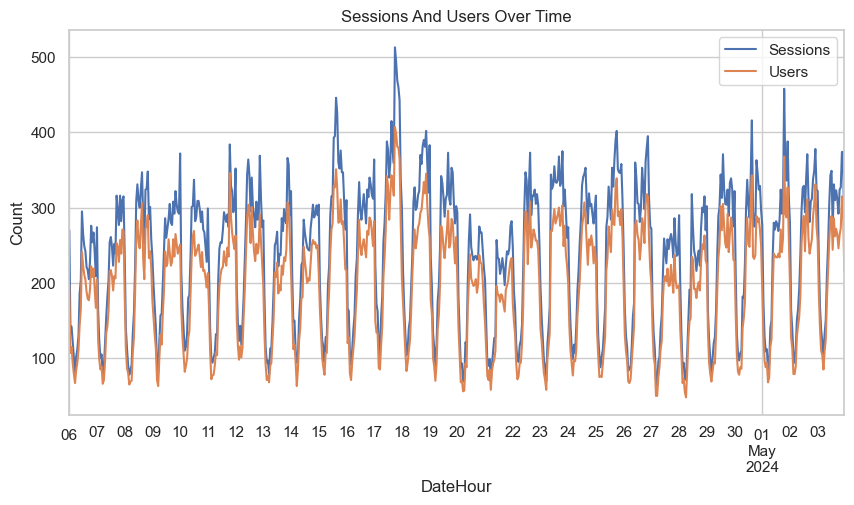

In [29]:
plt.figure(figsize=(10,5))
df.groupby("DateHour")[["Sessions","Users"]].sum().plot(ax=plt.gca())
plt.title("Sessions And Users Over Time")
plt.xlabel("DateHour")
plt.ylabel("Count")
plt.show()

### total users by channel

C:\Users\A\AppData\Local\Temp\ipykernel_2420\2958474618.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="Channel group",y="Users",estimator=np.sum,palette="magma")


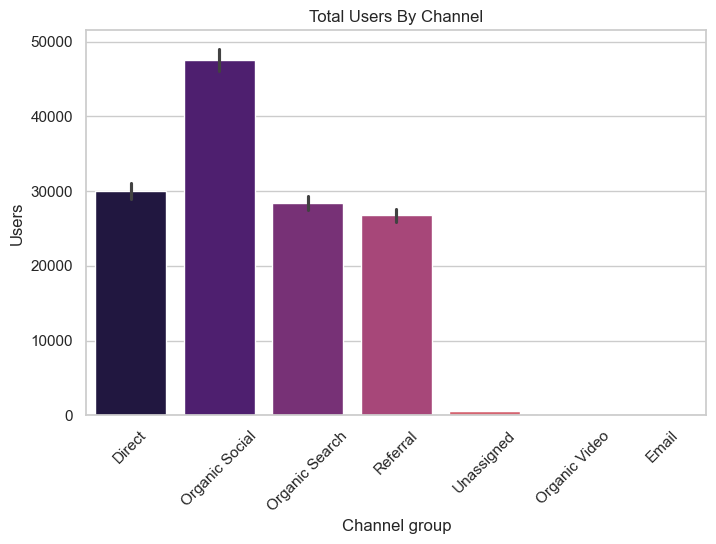

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Channel group",y="Users",estimator=np.sum,palette="magma")
plt.title("Total Users By Channel")
plt.xticks(rotation=45)
plt.show()

### Average engagement time by channel

C:\Users\A\AppData\Local\Temp\ipykernel_2420\3131344562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="Channel group",y="Average engagement time per session",estimator=np.mean,palette="magma")


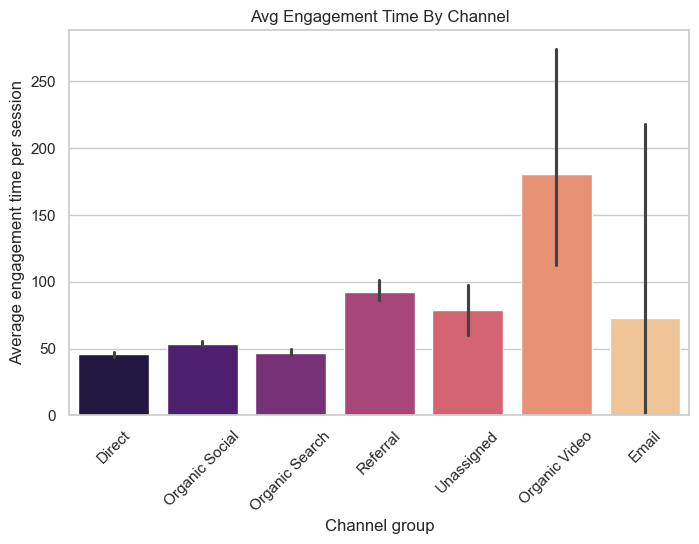

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Channel group",y="Average engagement time per session",estimator=np.mean,palette="magma")
plt.title("Avg Engagement Time By Channel")
plt.xticks(rotation=45)
plt.show()

### Engagement Rate Distribution By Channel

C:\Users\A\AppData\Local\Temp\ipykernel_2420\2401956918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Channel group",y="Engagement rate",palette="coolwarm")


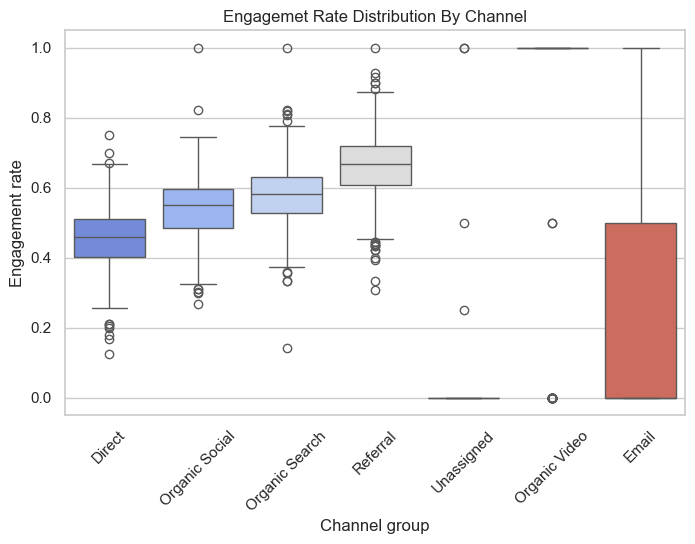

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Channel group",y="Engagement rate",palette="coolwarm")
plt.title("Engagemet Rate Distribution By Channel")
plt.xticks(rotation=45)
plt.show()

### Engaged Vs Non-Engaged Sessions

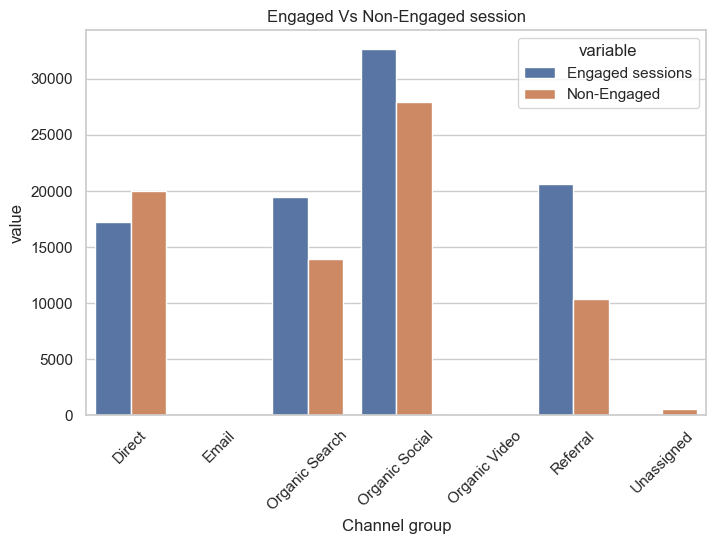

In [33]:
session_df=df.groupby("Channel group")[["Sessions","Engaged sessions"]].sum().reset_index()
session_df["Non-Engaged"]=session_df["Sessions"]-session_df["Engaged sessions"]
session_df_melted=session_df.melt(id_vars="Channel group",value_vars=["Engaged sessions","Non-Engaged"])

plt.figure(figsize=(8,5))
sns.barplot(data=session_df_melted,x="Channel group",y="value",hue="variable")
plt.title("Engaged Vs Non-Engaged session")
plt.xticks(rotation=45)
plt.show()

### Traffic By Hour And Channel

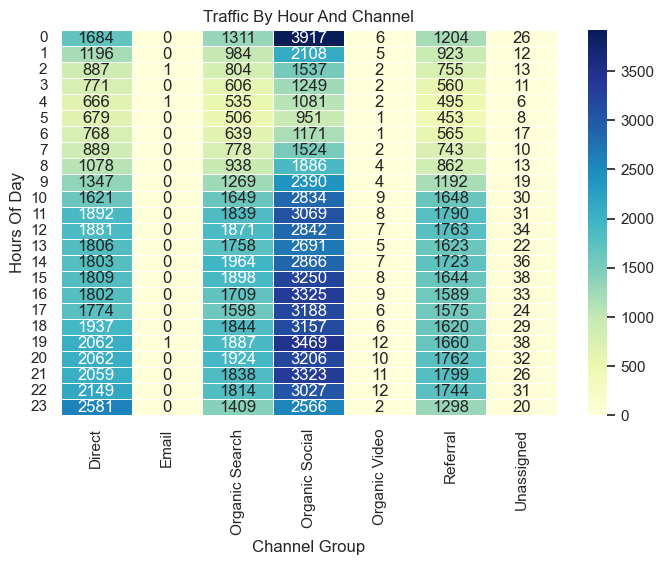

In [34]:
heatmap_data=df.groupby(["Hour","Channel group"])["Sessions"].sum().unstack().fillna(0)

plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data,cmap="YlGnBu",linewidths=.5,annot=True,fmt=".0f")
plt.title("Traffic By Hour And Channel")
plt.xlabel("Channel Group")
plt.ylabel(("Hours Of Day"))
plt.show()

### Engagement Rate Vs Session Over Time

In [35]:
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged session per user,Event per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


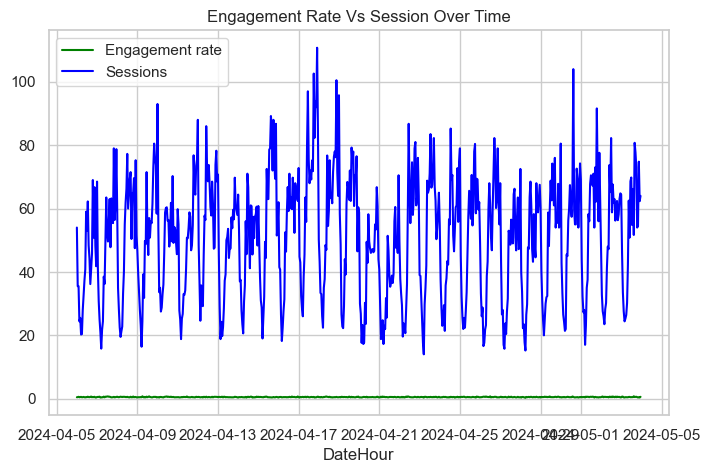

In [36]:
df_plot=df.groupby("DateHour")[["Engagement rate","Sessions"]].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(df_plot["DateHour"],df_plot["Engagement rate"], label="Engagement rate",color="green")
plt.plot(df_plot["DateHour"],df_plot["Sessions"], label="Sessions",color="blue")
plt.title("Engagement Rate Vs Session Over Time")
plt.xlabel("DateHour")
plt.legend()
plt.grid(True)
plt.show()

### 📊 Conclusion of Website Analysis Project

The analysis of the website dataset provides valuable insights into user behavior, traffic sources, and engagement performance across different channels and time periods.

🔹 1. Overall Traffic Trends
Both users and sessions show a consistent trend over time, indicating stable website activity.
Peaks in traffic suggest specific time periods where user activity is higher, which can be leveraged for targeted campaigns.

🔹 2. Channel Performance
Different channel groups contribute unevenly to total traffic.
Some channels generate high user volume but lower engagement, while others bring fewer but more engaged users.
This highlights the importance of focusing not just on traffic quantity but also on traffic quality.

🔹 3. User Engagement Insights
Channels differ significantly in:
Average engagement time,
Engagement rate,
Channels with higher engagement time indicate more relevant or high-quality traffic.
The presence of non-engaged sessions suggests opportunities to improve content or landing pages.

🔹 4. Engaged vs Non-Engaged Sessions
A noticeable portion of sessions are non-engaged, meaning users leave quickly.
This indicates:
Possible UX/UI issues,
Irrelevant traffic sources,
Weak landing page optimization.

🔹 5. Time-Based Traffic Patterns
Traffic varies by hour, showing clear peak activity periods during the day.
Identifying these peak hours helps in:
Scheduling marketing campaigns,
Posting content at optimal times,
Improving server/resource planning.

🔹 6. Relationship Between Sessions & Engagement
Engagement rate does not always increase with sessions.
Higher traffic does not guarantee better engagement, emphasizing:
Need for targeted marketing,
Better user experience optimization.


🎯 Final Insight-

Overall, the website performs well in attracting traffic, but there is scope for improving user engagement and reducing bounce/non-engaged sessions. By optimizing high-performing channels and improving underperforming ones, the website can achieve better conversion and user retention.

🚀 Recommendations-

Focus on high-engagement channels for marketing investment.
Improve landing pages to reduce non-engaged sessions.
Use peak hour insights for campaign timing.
Optimize content for better user interaction and retention.